# M11: HC vs. PD SSVEP comparison

`PLANssveps.md` M11: response grids, a per-pixel difference map, and group comparisons for HC (CTR) vs. PD -- raw and percent change, descriptive (pixel-level) and inferential (subject-level, M9's recommended `ramp_slope_red` outcome).

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import pingouin as pg

import analysis
import permutation
import plotting

runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()
troughs_df = pd.read_csv('../files/subject_troughs.csv')
SESSION = 1  # every subject has a session-1 row

categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
]
analysis.subjects_in_group(metadata_df, SESSION, group='CTR'), analysis.subjects_in_group(metadata_df, SESSION, group='PD')

(['MET000',
  'MET001',
  'MET002',
  'MET003',
  'MET004',
  'MET005',
  'MET006',
  'MET007',
  'MET008',
  'MET009',
  'MET010',
  'MET011',
  'MET012',
  'MET018',
  'MET020',
  'MET021',
  'MET022',
  'MET023',
  'MET024',
  'MET026',
  'MET027'],
 ['MET025', 'MET030', 'MET037', 'MET038', 'MET039', 'MET040'])

## Response grids, side by side

Raw first, then percent change from baseline (the project's primary outcome measure -- `docs/methods.md`).

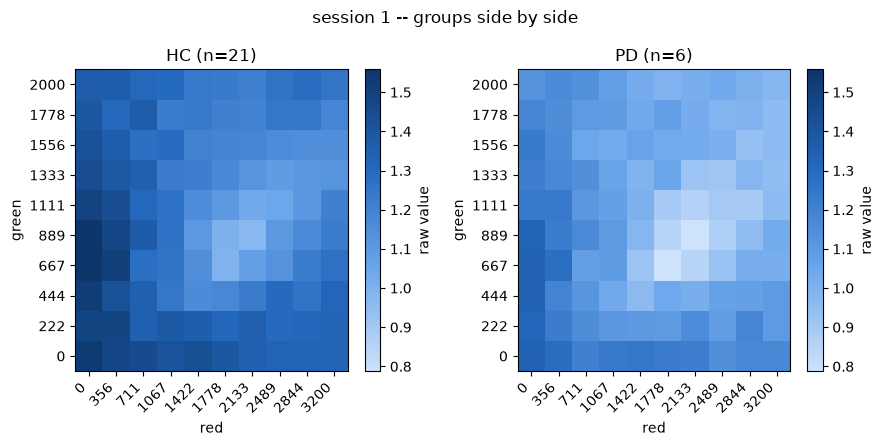

In [2]:
plotting.plot_groups_side_by_side(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=None);

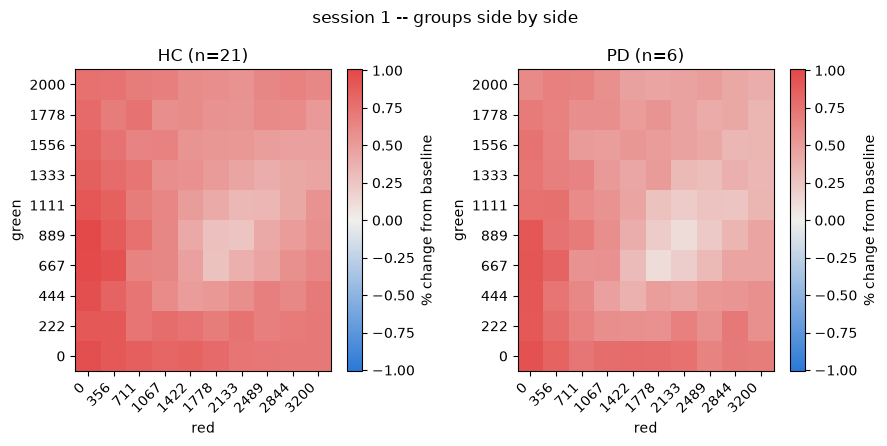

In [3]:
plotting.plot_groups_side_by_side(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=analysis.DEFAULT_NORMALIZE);

## Difference grid: HC - PD

`permutation_test_size` already computes `grid1.mean() - grid2.mean()` internally as `zdiff` (z-scored against its own permutation null) and `plot_permutation_test_size` renders it as the first panel -- reused directly rather than building a new difference-grid helper. Positive (red) = HC higher than PD at that cell.

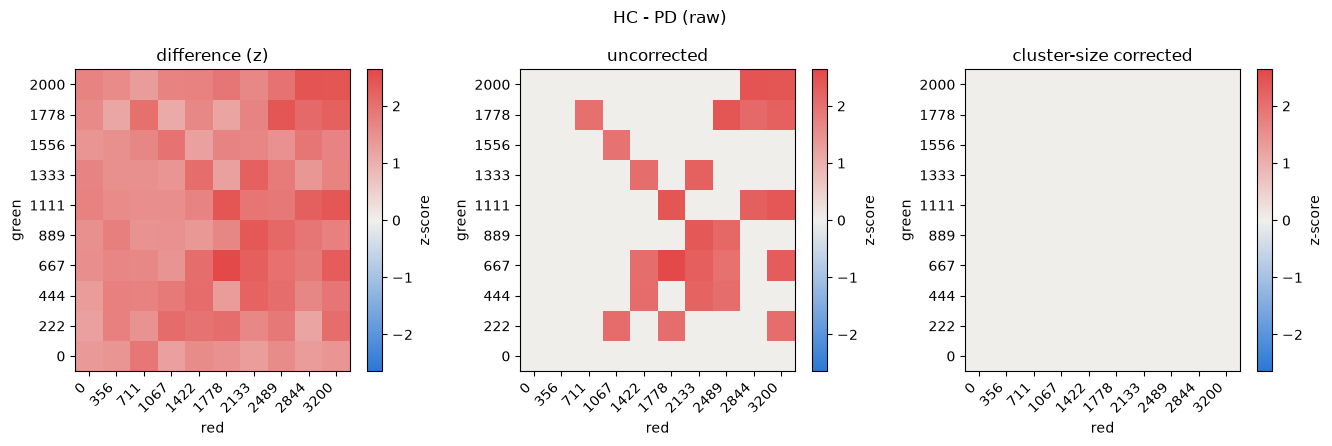

In [4]:
raw_diff = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, group1='CTR', group2='PD', normalize=None, seed=0)
plotting.plot_permutation_test_size(raw_diff, title='HC - PD (raw)');

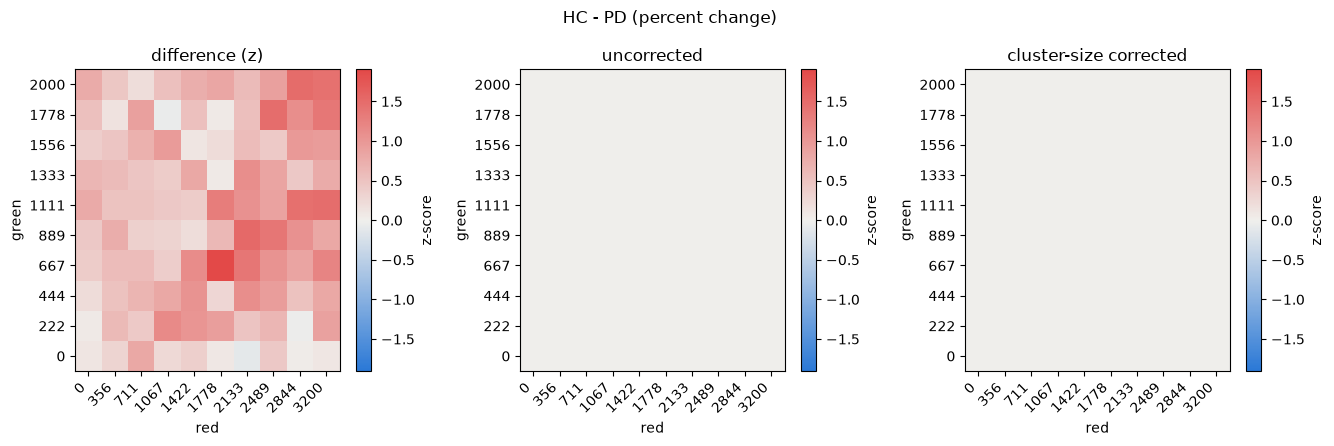

In [5]:
pct_diff = permutation.permutation_test_size(runmap_df, baselines_df, metadata_df, SESSION, group1='CTR', group2='PD', normalize=analysis.DEFAULT_NORMALIZE, seed=0)
plotting.plot_permutation_test_size(pct_diff, title='HC - PD (percent change)');

## Boxplots and statistical comparison

**Subject-level, the number this section's significance claim rests on**: `ramp_slope_red` per subject (M9's most reliable outcome, ICC=0.85, defined for every subject regardless of whether their trough was located) from the already-persisted `subject_troughs.csv` -- no rebuild. Mann-Whitney U, matching `beh/scripts/features.py`'s `compare_shape_feature` convention for a two-group comparison.

,U_val,alternative,p_val,RBC,CLES
MWU,60.0,two-sided,0.887166,-0.047619,0.47619


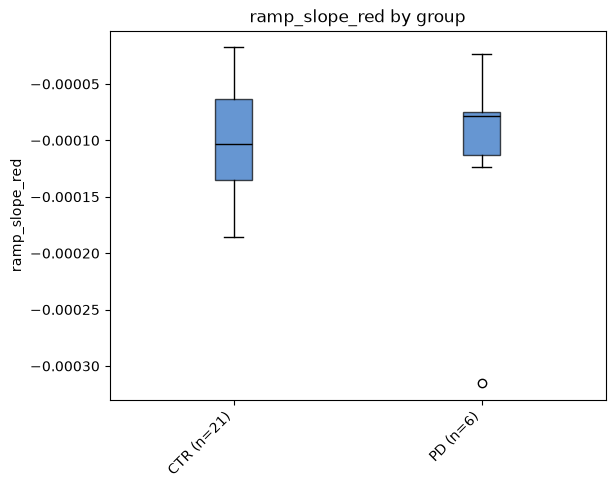

In [6]:
hc_pd = troughs_df[(troughs_df['session'] == SESSION) & (troughs_df['group'].isin(['CTR', 'PD']))]
plotting.plot_troughs_boxplot(hc_pd, 'ramp_slope_red', 'group', ylabel='ramp_slope_red');

hc_vals = hc_pd.loc[hc_pd['group'] == 'CTR', 'ramp_slope_red']
pd_vals = hc_pd.loc[hc_pd['group'] == 'PD', 'ramp_slope_red']
pg.mwu(hc_vals, pd_vals)

**Pixel-level, descriptive only -- not a second significance claim.** Pools 100 correlated grid cells per subject as if independent, which M9 flagged as a less trustworthy basis for a group comparison than `ramp_slope_red` above; shown here purely as a picture of the raw response spread, same style as `04_distributions.ipynb`.

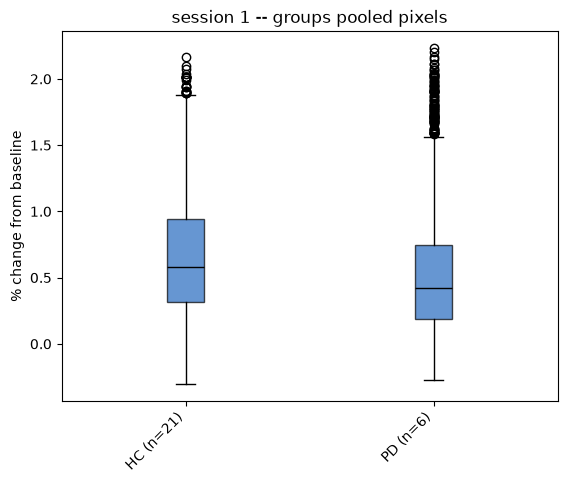

In [7]:
plotting.plot_groups_pooled_boxplot(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=analysis.DEFAULT_NORMALIZE);

## Summary

HC (n=21) vs. PD (n=6), session 1. No significant difference on any of the three measures here: the difference grid shows no correction-surviving cluster (raw or percent), and `ramp_slope_red`'s Mann-Whitney U=60, p=0.89, RBC=-0.05 -- essentially no effect, consistent with everything else in this project regarding PD (M7: within-subject SD not elevated; M9/M10: PD never separates from CTR on any recommended outcome). PD remains underpowered (n=6) rather than confirmed indistinguishable -- more PD subjects is the standing recommendation, not a new analysis.